In [21]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

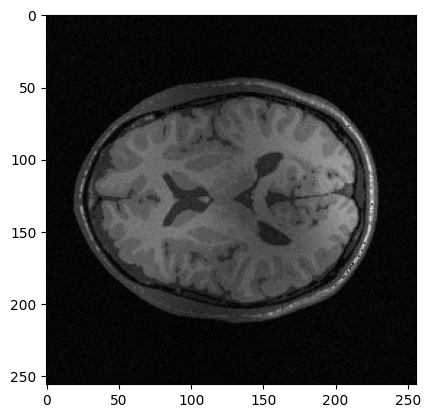

In [195]:
# load data
with h5py.File('data/assignmentSegmentBrain.mat', 'r') as f:
    noisyImage = np.array(f['imageData'])
    imageMask = np.array(f['imageMask'])

plt.imshow(noisyImage, cmap='gray')

In [210]:
image_height, image_width  = noisyImage.shape

# fuzziness control
q = 2

# number of classes (+1 for the background)
K = 4

# number of pixels
num_pixels = image_width * image_height

# gaussian kernel size
kernel_size = 10

# gaussian kernel variance, to be adjusted based on bias field
sigma = 6

# grid of coords
x_coords = np.arange(image_width)
y_coords = np.arange(image_height)
x_grid, y_grid = np.meshgrid(x_coords, y_coords)

# flattening coords
x_flat = x_grid.flatten()
y_flat = y_grid.flatten()

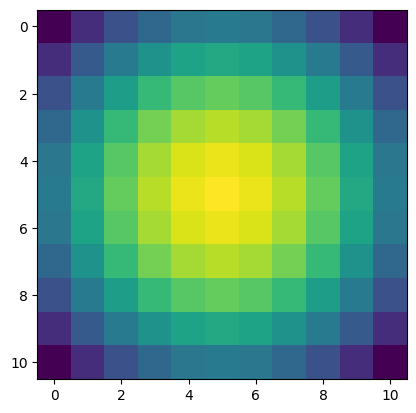

In [211]:
def create_localized_gaussian_weights():
    half_size = kernel_size // 2
    x_coords = np.arange(-half_size, half_size + 1)
    y_coords = np.arange(-half_size, half_size + 1)
    x_grid, y_grid = np.meshgrid(x_coords, y_coords)

    distances_squared = (x_grid)**2 + (y_grid)**2

    gaussian_weights = np.exp(-distances_squared / (2 * sigma**2))
    gaussian_weights /= np.sum(gaussian_weights)

    return gaussian_weights

test_weights = create_localized_gaussian_weights()
plt.imshow(test_weights)

In [246]:
def update_class_means_localized(image, u, b):
    class_means = np.zeros(K) 

    # maybe don't update the last class's mean?
    for k in range(K-1):
        numerator = 0.0
        denominator = 0.0
        
        for j in range(num_pixels):
            # coords of central pixel
            center_x = x_flat[j]
            center_y = y_flat[j]

            # create a matrix c containing pairs (x, y) with center at (center_x, center_y)
            half_size = kernel_size // 2
            x_offsets = np.arange(-half_size, half_size + 1)
            y_offsets = np.arange(-half_size, half_size + 1)
            x_grid, y_grid = np.meshgrid(x_offsets, y_offsets, indexing='ij')
            c = np.stack((center_x + x_grid.ravel(), center_y + y_grid.ravel()), axis=-1)

            # filtering invalid indices
            valid_mask = (c[:, 0] >= 0) & (c[:, 0] < image_width) & (c[:, 1] >= 0) & (c[:, 1] < image_height)
            valid_c = c[valid_mask]

            # converting to indices
            local_indices = np.ravel_multi_index((valid_c[:, 1], valid_c[:, 0]), (image_height, image_width))

            # gaussian kernel
            full_gaussian_weights = create_localized_gaussian_weights().ravel()

            gaussian_weights = full_gaussian_weights[valid_mask]

            # normalize gaussian weights to make sum 1
            gaussian_weights /= np.sum(gaussian_weights)
            
            # use local biases for weighted sum
            weighted_sum_numerator = np.sum(gaussian_weights * b[local_indices])
            weighted_sum_denominator = np.sum(gaussian_weights * b[local_indices]**2)
            
            numerator += (u[j, k] ** q) * image[j] * weighted_sum_numerator
            denominator += (u[j, k] ** q) * weighted_sum_denominator
        
        # setting value for kth class mean
        class_means[k] = numerator / denominator if denominator != 0 else 0

    return class_means

In [227]:
def update_memberships_localized(image, class_means, b):
    u = np.zeros((num_pixels, K))  

    for j in range(num_pixels):
        # coords of pixel
        center_x = x_flat[j]
        center_y = y_flat[j]

        # create a matrix c containing pairs (x, y) with center at (center_x, center_y)
        half_size = kernel_size // 2
        x_offsets = np.arange(-half_size, half_size + 1)
        y_offsets = np.arange(-half_size, half_size + 1)
        x_grid, y_grid = np.meshgrid(x_offsets, y_offsets, indexing='ij')
        c = np.stack((center_x + x_grid.ravel(), center_y + y_grid.ravel()), axis=-1)

        # filtering invalid indices
        valid_mask = (c[:, 0] >= 0) & (c[:, 0] < image_width) & (c[:, 1] >= 0) & (c[:, 1] < image_height)
        valid_c = c[valid_mask]

        # converting to indices in image
        local_indices = np.ravel_multi_index((valid_c[:, 1], valid_c[:, 0]), (image_height, image_width))

        # gaussian kernel 
        full_gaussian_weights = create_localized_gaussian_weights().ravel()
        gaussian_weights = full_gaussian_weights[valid_mask]

        # normalize gaussian weights to make sum 1
        gaussian_weights /= np.sum(gaussian_weights)

        # calculating d_kj using local biases
        d_kj = np.zeros(K)
        for k in range(K):
            d_kj[k] = np.sum(gaussian_weights * (image[j] - class_means[k] * b[local_indices])**2)
            d_kj[k] = 0.001 if d_kj[k] == 0 else d_kj[k]

        # setting membership values of all classes for that pixel
        for k in range(K):
            denominator = np.sum((1 / d_kj)**(1 / (q - 1)))
            u[j, k] = (1 / d_kj[k])**(1 / (q - 1)) / denominator if denominator != 0 else 0
            
    return u

In [228]:
def update_bias_field_localized(image, u, class_means):
    b = np.zeros(num_pixels) 

    for i in range(num_pixels):
        # coords of current pixel
        center_x = x_flat[i]
        center_y = y_flat[i]

        # create a matrix c containing pairs (x, y) with center at (center_x, center_y)
        half_size = kernel_size // 2
        x_offsets = np.arange(-half_size, half_size + 1)
        y_offsets = np.arange(-half_size, half_size + 1)
        x_grid, y_grid = np.meshgrid(x_offsets, y_offsets, indexing='ij')
        c = np.stack((center_x + x_grid.ravel(), center_y + y_grid.ravel()), axis=-1)

        # filtering invalid indices
        valid_mask = (c[:, 0] >= 0) & (c[:, 0] < image_width) & (c[:, 1] >= 0) & (c[:, 1] < image_height)
        valid_c = c[valid_mask]

        # converting to indices in image
        local_indices = np.ravel_multi_index((valid_c[:, 1], valid_c[:, 0]), (image_height, image_width))

        # gaussian kernel 
        full_gaussian_weights = create_localized_gaussian_weights().ravel()
        gaussian_weights = full_gaussian_weights[valid_mask]

        # normalize gaussian weights to make sum 1
        gaussian_weights /= np.sum(gaussian_weights)

        numerator = np.sum(
            gaussian_weights[:, np.newaxis] * 
            image[local_indices, np.newaxis] * 
            (u[local_indices, :]**q) * 
            class_means[np.newaxis, :]
        )

        denominator = np.sum(
            gaussian_weights[:, np.newaxis] * 
            (u[local_indices, :]**q) * 
            (class_means[np.newaxis, :]**2)
        )

        # set bias field for pixel i
        b[i] = numerator / denominator if denominator != 0 else 0

    return b

In [238]:
def calculate_objective(image, u, class_means, b):
    objective = 0.0

    flattened_image = image.ravel()

    for j in range(num_pixels):
        # coords of pixel
        center_x = x_flat[j]
        center_y = y_flat[j]

        # create a matrix c containing pairs (x, y) with center at (center_x, center_y)
        half_size = kernel_size // 2
        x_offsets = np.arange(-half_size, half_size + 1)
        y_offsets = np.arange(-half_size, half_size + 1)
        x_grid, y_grid = np.meshgrid(x_offsets, y_offsets, indexing='ij')
        c = np.stack((center_x + x_grid.ravel(), center_y + y_grid.ravel()), axis=-1)

        # filtering invalid indices
        valid_mask = (c[:, 0] >= 0) & (c[:, 0] < image_width) & (c[:, 1] >= 0) & (c[:, 1] < image_height)
        valid_c = c[valid_mask]

        # converting to indices
        local_indices = np.ravel_multi_index((valid_c[:, 1], valid_c[:, 0]), (image_height, image_width))

        # gaussian kernel 
        full_gaussian_weights = create_localized_gaussian_weights().ravel()
        gaussian_weights = full_gaussian_weights[valid_mask]

        # normalize gaussian weights to make sum 1
        gaussian_weights /= np.sum(gaussian_weights)

        # objective function calculation
        for k in range(K):
            d_kj = np.sum(gaussian_weights * (flattened_image[j] - class_means[k] * b[local_indices])**2)
            objective += (u[j, k] ** q) * d_kj

    return objective

def fcm_segmentation(image, mask, max_iter=100, tol=1e-5):
    # all update functions take flattened image as input
    flattened_image = image.flatten()
    num_pixels = flattened_image.size

    # initialization of memberships
    U = np.random.rand(num_pixels, K - 1)
    # setting background class membership to 1 for masked-out pixels
    background_indices = np.where(mask.flatten() == 0)[0]
    U = np.hstack([U, np.zeros((num_pixels, 1))])
    U[background_indices, -1] = 1 
    U[background_indices, :-1] = 0  

    # normalize to make sum 1
    U /= np.sum(U, axis=1, keepdims=True)

    # initialization of class means
    class_means = np.random.rand(K)
    class_means[-1] = 0  # Set last class mean (background) to 0

    # initialization of bias field
    b = np.ones(num_pixels)

    objective_function = []

    for iteration in range(max_iter):
        print("Iteration number : ", iteration)

        print("Updating class means")
        class_means = update_class_means_localized(flattened_image, U, b)

        print("Updating memberships")
        U = update_memberships_localized(flattened_image, class_means, b)

        # Fix background memberships
        U[background_indices, -1] = 1
        U[background_indices, :-1] = 0

        print("Updating bias field")
        b = update_bias_field_localized(flattened_image, U, class_means)

        J = calculate_objective(flattened_image, U, class_means, b)
        objective_function.append(J)

        if iteration > 0 and abs(J - prev_J) < tol:
            print(f"Converged after {iteration} iterations.")
            break

        prev_J = J

    return U, class_means, b, objective_function

In [255]:
def plot_memberships(U):
    for k in range(K):
        plt.figure()
        plt.title(f'Membership for Class {k+1}')
        membership_image = U[:, k].reshape((image_height, image_width))
        plt.imshow(membership_image, cmap='gray')
        plt.colorbar()
        plt.show()

In [256]:
def plot_objective_function(objective_function):
    plt.figure()
    plt.title('Objective Function vs Iteration')
    plt.plot(objective_function, marker='o')
    plt.xlabel('Iteration')
    plt.ylabel('Objective Function Value')
    plt.grid(True)
    plt.show()

In [257]:
def plot_bias_estimate(b):
    plt.figure()
    plt.title('Bias Estimate')
    bias_image = b.reshape((image_height, image_width))
    plt.imshow(bias_image, cmap='gray')
    plt.colorbar(label='Bias Value')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()

In [258]:
def plot_bias_removed_image(U, class_means):
    # Compute the bias-removed image
    bias_removed_image = np.sum(U * class_means[np.newaxis, :], axis=1)

    # Reshape to the original image shape
    bias_removed_image = bias_removed_image.reshape((image_height, image_width))

    # Plot the bias-removed image
    plt.figure()
    plt.title('Bias-Removed Image')
    plt.imshow(bias_removed_image, cmap='gray')
    plt.colorbar(label='Intensity')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()

In [259]:
def plot_residual_image(image, U, class_means, b):
    image = image.ravel()

    # Compute the bias-removed image
    bias_removed_image = np.sum(U * class_means[np.newaxis, :], axis=1)

    # Compute the residual image
    residual_image = image - bias_removed_image * b

    # Reshape to the original image shape
    residual_image = residual_image.reshape((image_height, image_width))
    print(np.max(residual_image))

    # Plot the residual image
    plt.figure()
    plt.title('Residual Image')
    plt.imshow(residual_image, cmap='gray')
    plt.colorbar(label='Residual Intensity')
    plt.xlabel('X-axis')
    plt.ylabel('Y-axis')
    plt.show()

In [247]:
__u, __class_means, __b, __objective = fcm_segmentation(noisyImage, imageMask, 15, 1e-5)

Iteration number :  0
Updating class means
Updating memberships
Updating bias field
Iteration number :  1
Updating class means
Updating memberships
Updating bias field
Iteration number :  2
Updating class means
Updating memberships
Updating bias field
Iteration number :  3
Updating class means
Updating memberships
Updating bias field
Iteration number :  4
Updating class means
Updating memberships
Updating bias field
Iteration number :  5
Updating class means
Updating memberships
Updating bias field
Iteration number :  6
Updating class means
Updating memberships
Updating bias field
Iteration number :  7
Updating class means
Updating memberships
Updating bias field
Iteration number :  8
Updating class means
Updating memberships
Updating bias field
Iteration number :  9
Updating class means
Updating memberships
Updating bias field
Iteration number :  10
Updating class means
Updating memberships
Updating bias field
Iteration number :  11
Updating class means
Updating memberships
Updating b

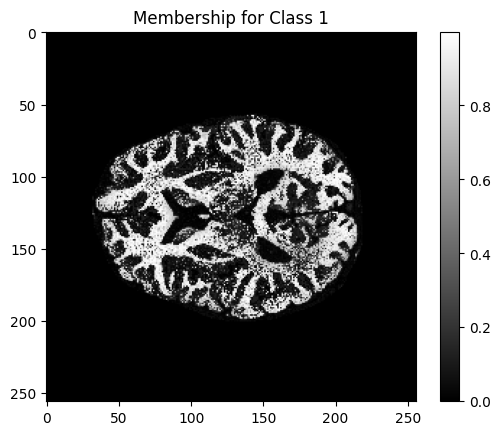

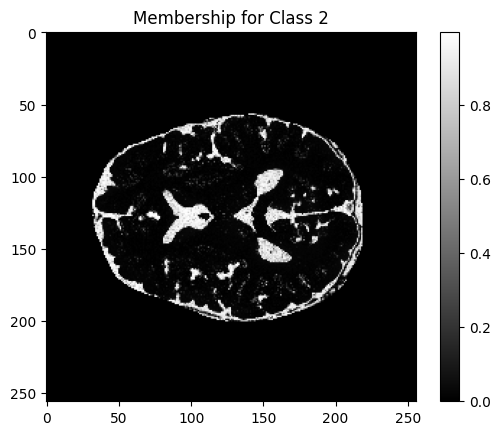

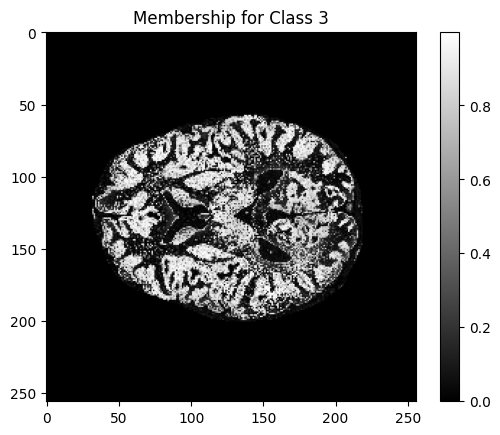

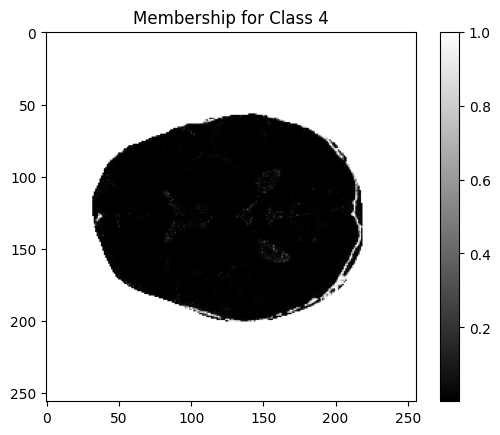

In [248]:
plot_memberships(__u)

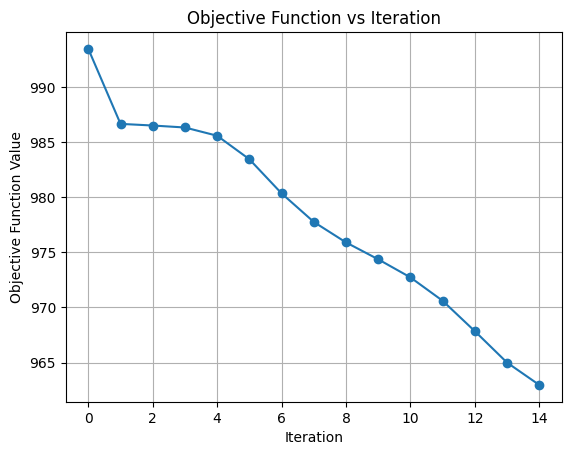

In [249]:
plot_objective_function(__objective)

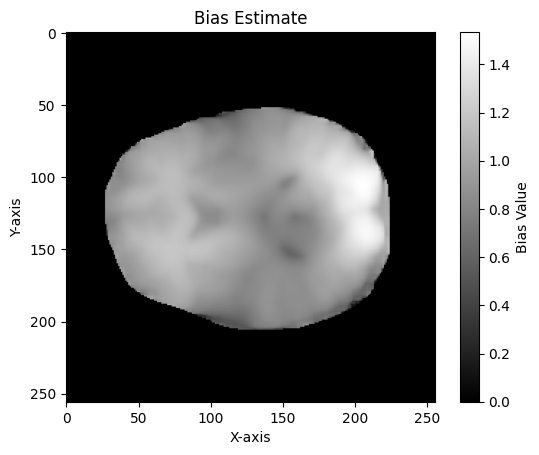

In [250]:
plot_bias_estimate(__b)

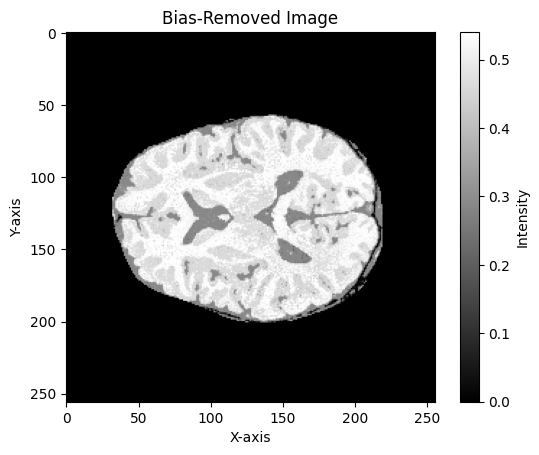

In [251]:
plot_bias_removed_image(__u, __class_means)

1.3859524726867676


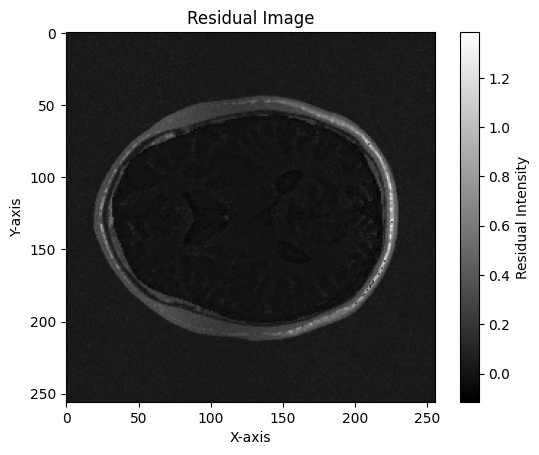

In [252]:
plot_residual_image(noisyImage, __u, __class_means, __b)

In [253]:
print(__class_means)

[0.54030573 0.28553791 0.46064138 0.        ]


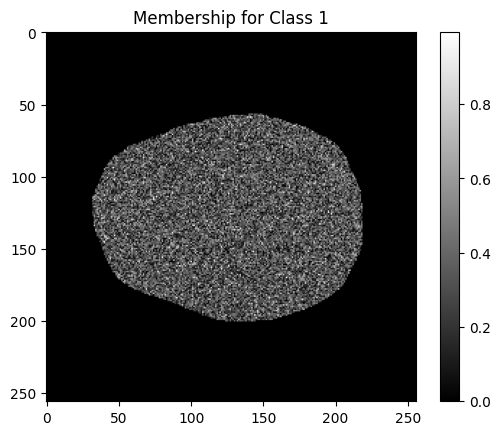

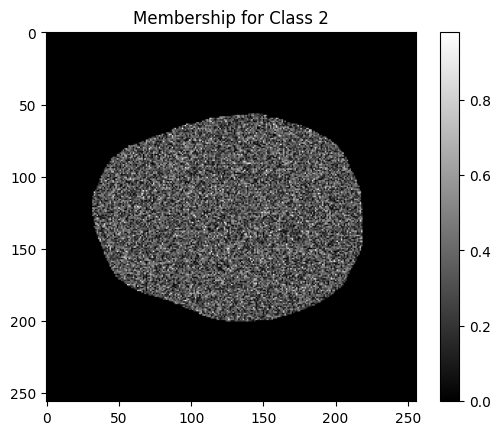

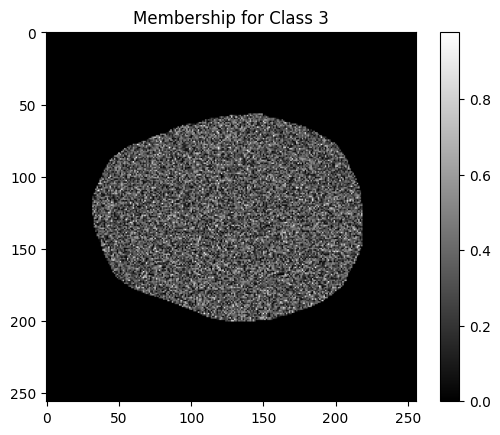

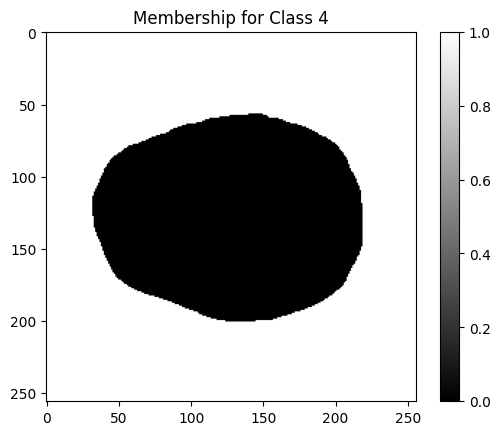

In [254]:
# initialization of memberships
U = np.random.rand(num_pixels, K - 1)
# setting background class membership to 1 for masked-out pixels
background_indices = np.where(imageMask.flatten() == 0)[0]
U = np.hstack([U, np.zeros((num_pixels, 1))])
U[background_indices, -1] = 1 
U[background_indices, :-1] = 0  

# normalize to make sum 1
U /= np.sum(U, axis=1, keepdims=True)

plot_memberships(U)

In [261]:
# initialization of class means
class_means = np.random.rand(K)
class_means[-1] = 0  # Set last class mean (background) to 0

print(class_means)

[0.06818729 0.50286959 0.65542129 0.        ]
